## Task 5: Model Explainability with Grad-CAM

In this notebook, we investigate whether our model focuses on clinically relevant regions of the images when predicting their class.

### 1. Select a trained classifier
For this task, we chose to use the finetuned resnet50 model from task 3, which is the best performing one.

In [2]:
import torch
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [3]:
class TransferResNet50(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        # Load pretrained ResNet50
        self.base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # Remove the final fully connected layer
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()

        # Freeze all layers in the base model
        for param in self.base_model.parameters():
            param.requires_grad = False

        # New classification head
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        features = self.base_model(x)
        output = self.classifier(features)
        return output

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = TransferResNet50(dropout_rate=0.5)
model.load_state_dict(torch.load("resnet50_transfer_finetuned.pth", map_location=device))
model = model.to(device)

Using device: cuda


In [5]:
def to_3_channels(x):
    """
    Converts grayscale images to 3 channels by repeating the channel dimension.
    Expected input shape: (N, H, W, 1) or (N, 1, H, W) or (N, H, W)
    Output shape: (N, 3, H, W)
    """
    if x.ndim == 3:  # (N, H, W)
        x = np.expand_dims(x, axis=-1)

    if x.shape[-1] == 1:  # (N, H, W, 1)
        x = np.transpose(x, (0, 3, 1, 2))  # -> (N, 1, H, W)

    if x.shape[1] == 1:  # (N, 1, H, W)
        x = np.repeat(x, 3, axis=1)  # -> (N, 3, H, W)

    return x.astype(np.float32)

X_test = to_3_channels(np.load("X_test.npy"))
y_test = np.load("y_test.npy")

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for image, label in zip(X_test_tensor, y_test_tensor):
        image = image.to(device).unsqueeze(0)
        label = label.to(device)

        output = model(image)
        prob = torch.sigmoid(output).item()

        all_preds.append(int(prob >= 0.5))
        all_labels.append(int(label.cpu().item()))

misclassified = 0
for pred, label in zip(all_preds, all_labels):
    if pred != label:
        print(f"Predicted: {pred}, Actual: {label}, Correct: {pred == label}")
        misclassified += 1
print(f"Total misclassified: {misclassified} out of {len(all_labels)}")

Predicted: 1, Actual: 0, Correct: False
Predicted: 1, Actual: 0, Correct: False
Predicted: 1, Actual: 0, Correct: False
Predicted: 1, Actual: 0, Correct: False
Predicted: 1, Actual: 0, Correct: False
Predicted: 0, Actual: 1, Correct: False
Predicted: 0, Actual: 1, Correct: False
Predicted: 0, Actual: 1, Correct: False
Predicted: 0, Actual: 1, Correct: False
Total misclassified: 9 out of 146


### 2. Implement Grad-CAM

Grad-CAM is applied to the last convolutional layer of the pretrained ResNet50 model to capture high-level visual features relevant for the classification task.

In [6]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activations)

    def save_activations(self, module, input, output):
        self.activations = output
        if output.requires_grad:
            self.activations.retain_grad()

target_layer = model.base_model.layer4[-1]
cam_engine = GradCAM(model, target_layer)

Grad-CAM heatmaps are generated using the gradients of the model prediction with respect to the selected convolutional layer for a set of test images.

In [7]:
def generate_heatmap(cam_engine, input_image):
    cam_engine.model.eval()

    # Enable gradients
    for param in cam_engine.model.parameters():
        param.requires_grad = True

    with torch.enable_grad():
        input_image = input_image.clone().detach().requires_grad_(True)

        cam_engine.model.zero_grad()
        output = cam_engine.model(input_image)

        score = output.view(-1)[0]
        score.backward()

        gradients = cam_engine.activations.grad
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        heatmap = torch.sum(weights * cam_engine.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)

        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap.detach().cpu().numpy()

The generated Grad-CAM heatmaps are resized and overlaid on the original X-ray images to visualize the regions that most influence the model’s predictions.

In [8]:
def overlay_heatmap(original_img, heatmap, ax=None, title="Grad-CAM"):
    original_img = np.array(original_img)

    if original_img.ndim == 3:
        original_img = original_img[0]

    original_img = original_img.astype(np.float32)
    original_img = (original_img - original_img.min()) / (original_img.max() - original_img.min() + 1e-8)

    heatmap_tensor = torch.tensor(heatmap, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    heatmap_resized = F.interpolate(
        heatmap_tensor,
        size=(original_img.shape[0], original_img.shape[1]),
        mode="bilinear",
        align_corners=False
    ).squeeze().cpu().numpy()
    heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (
        heatmap_resized.max() - heatmap_resized.min() + 1e-8
    )

    if ax is None:
        plt.figure(figsize=(6, 6))
        ax = plt.gca()
        standalone = True
    else:
        standalone = False

    ax.imshow(original_img, cmap="gray")
    ax.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

    if standalone:
        plt.show()

Now we visualize Grad-CAM results for five correctly classified healthy images, five correctly classified severe osteoarthritis images and five wrongly classified images.

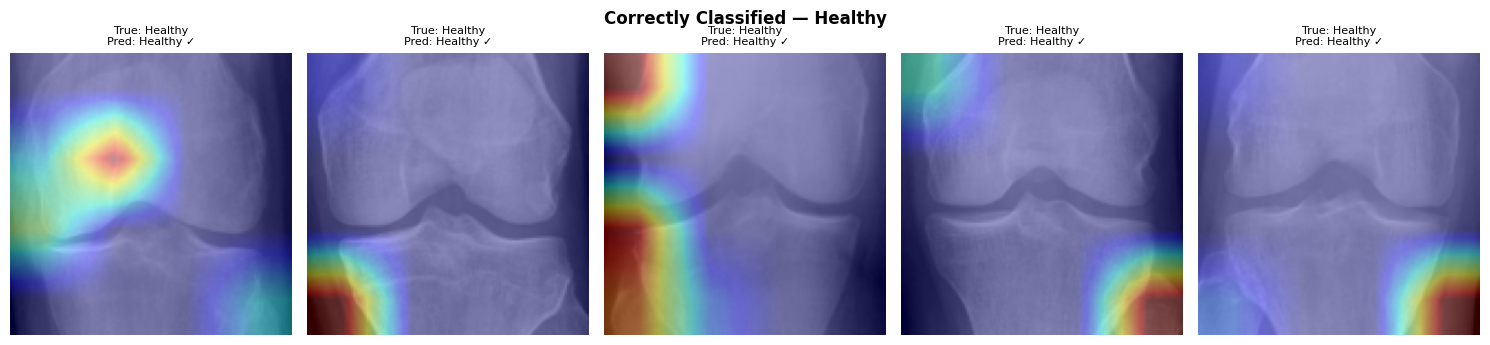

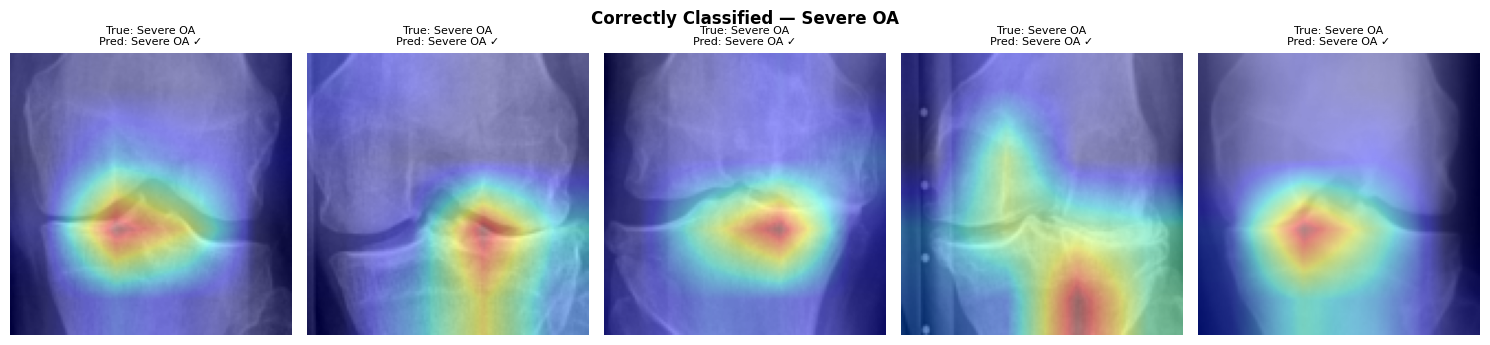

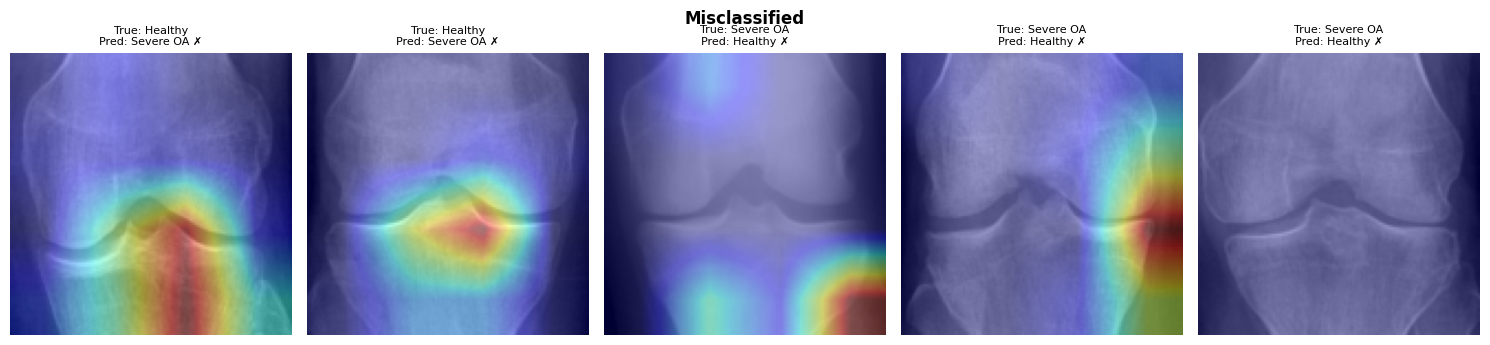

In [18]:
N_PER_GROUP = 5

correct_healthy   = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p == l == 0]
correct_severe    = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p == l == 1]
misclassified_idx = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]

rng = np.random.default_rng(46)

def sample(lst, n):
    n = min(n, len(lst))
    return rng.choice(lst, size=n, replace=False).tolist()

groups = {
    "Correctly Classified — Healthy":   sample(correct_healthy,   N_PER_GROUP),
    "Correctly Classified — Severe OA": sample(correct_severe,    N_PER_GROUP),
    "Misclassified":                    sample(misclassified_idx, N_PER_GROUP),
}

label_names = {0: "Healthy", 1: "Severe OA"}

for group_title, indices in groups.items():
    fig, axes = plt.subplots(1, N_PER_GROUP, figsize=(3 * N_PER_GROUP, 3.5))
    fig.suptitle(group_title, fontsize=12, fontweight="bold")

    for ax, idx in zip(axes, indices):
        img_tensor = X_test_tensor[idx].unsqueeze(0).to(device)
        heatmap = generate_heatmap(cam_engine, img_tensor)

        pred, true = all_preds[idx], all_labels[idx]
        title = f"True: {label_names[true]}\nPred: {label_names[pred]} {'✓' if pred == true else '✗'}"

        overlay_heatmap(X_test[idx], heatmap, ax=ax, title=title)

    plt.tight_layout()
    plt.savefig(f"gradcam_{group_title[:25].replace(' ', '_').replace('—','').strip()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

These results show clearly that the highligthed regions differ between healty and severe cases. 

When classifying a severe case, the model correctly focusses on the joint space. So if these features have a high activation the model will likely classify it as a severe case. This shows that the model is able to detect narrow joint spaces and correctly classify images that show these features. Focussing on the joint space is clinicly meaningful because this is one of the most dominant features a knee with OA shows.


If other features have a higher activation then the joint space features, the model will likely classify it as healthy. The lack of a consistent activation pattern across healthy images suggests the model hasn't learned a clear positive signal for healthy knees. This is not clinicly meaningful. Instead it should try to make a distinction between the types of joint spaces and based on that classify the image.

The mispredicted cases support this hypothese. Healthy images that have a high activation for the joint space features get classified as unhealthy, while unhealthy images with low activation for the joint space features get classified as healthy.

This suggests the model has not learned a symmetric decision boundary — it recognises the presence of OA through joint space narrowing, but classifies healthy knees by the absence of that signal rather than any clinically meaningful positive indicator of a healthy joint.

There are examples where the model focusses on irrelevant structures, mostly when the joint space feature map is not dominant. This is visible in the healthy knee examples, where the heatmap highlights surrounding bone and soft tissue regions that carry no diagnostic relevance for OA, effectively focusing on irrelevant structures.